# Lab 15: K-means with varying K

Generated 500-point four-cluster dataset (seed 42). Compares K=2..8 with inertia and silhouette; visualizes K=2,4,6.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


K: 2 inertia: 15239.01767969875 silhouette: 0.6130119939502626
K: 3 inertia: 3002.941738783511 silhouette: 0.7920693041719874
K: 4 inertia: 464.95626823545086 silhouette: 0.8547261023518763
K: 5 inertia: 419.4160278279196 silhouette: 0.7183922358582124
K: 6 inertia: 376.9979642709749 silhouette: 0.5973640587386501
K: 7 inertia: 336.95877417528396 silhouette: 0.4820438429493328
K: 8 inertia: 291.4378119464509 silhouette: 0.34901293845387216


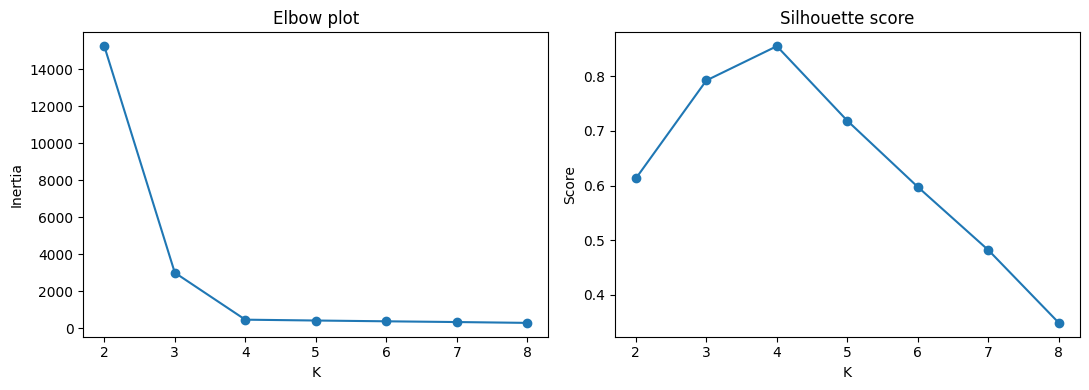

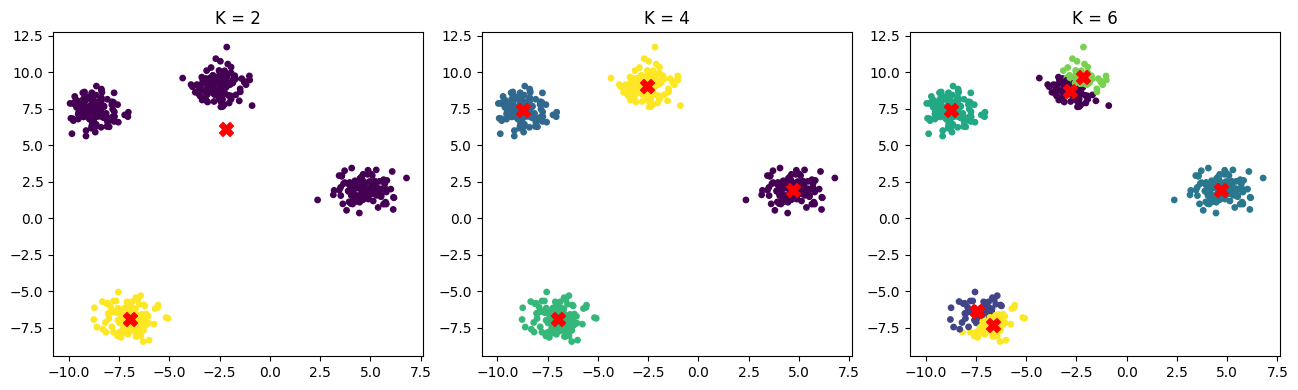

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
X,true_labels=make_blobs(n_samples=500,centers=4,cluster_std=.7,random_state=42)
inertias=[];silhouettes=[]
for k in range(2,9):
 model=KMeans(n_clusters=k,random_state=42,n_init=10);labels=model.fit_predict(X);inertias.append(model.inertia_);silhouettes.append(silhouette_score(X,labels));print('K:',k,'inertia:',model.inertia_,'silhouette:',silhouettes[-1])
fig,axs=plt.subplots(1,2,figsize=(11,4));axs[0].plot(range(2,9),inertias,marker='o');axs[0].set(title='Elbow plot',xlabel='K',ylabel='Inertia');axs[1].plot(range(2,9),silhouettes,marker='o');axs[1].set(title='Silhouette score',xlabel='K',ylabel='Score');plt.tight_layout();plt.show()
fig,axs=plt.subplots(1,3,figsize=(13,4))
for ax,k in zip(axs,[2,4,6]):
 model=KMeans(n_clusters=k,random_state=42,n_init=10);labels=model.fit_predict(X);ax.scatter(X[:,0],X[:,1],c=labels,cmap='viridis',s=15);ax.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],marker='X',c='red',s=100);ax.set_title(f'K = {k}')
plt.tight_layout();plt.show()
